# 03 — Exploratory Data Analysis & Feature Engineering


The cliché is true: data scientists spend ~80% of their time cleaning and
shaping data. This notebook is that 80%, made systematic. Get this right and
every later model gets easier, cheaper, and more accurate — and we end with
the most common feature‑engineering self‑inflicted wound: **target leakage
from a naive target encoding** (§3.2 confounding's cousin).

## What you'll be able to do after this notebook

1. Run a **structured EDA** that surfaces data quality issues before they bite.
2. Handle **missing values** and **outliers** deliberately, not by default.
3. Tame **skewed** numeric features (§1.3) and **scale** them sensibly
 (§1.2).
4. Encode **categorical** features three ways and know when each applies.
5. Engineer features that carry more signal than the raw columns.
6. Spot **target leakage** the moment a feature looks too good to be true.

## The standard process (this whole notebook is one pass through it)

```
 Explore -> Clean -> Transform -> Engineer -> (ready to model)
```

## 1. EDA framework: ask these questions of *every* dataset

A checklist you can reuse forever:

1. **Shape** — how many rows, how many columns? Does that match expectation?
2. **Types** — is each column the type you think it is? (numbers stored as
 text, dates as strings, etc.)
3. **Missingness** — how many nulls per column, and is the pattern random or
 structural?
4. **Distributions** — for each numeric column, what's the spread? Skewed?
 Bounded? Are there impossible values (negatives where none make sense)?
5. **Categoricals** — how many levels per category? Any rare levels? Typos?
6. **Targets** — is the target balanced? What's the trivial baseline?
7. **Relationships** — which features correlate with the target and with each
 other?

We'll walk through each on a real, messy dataset — **Ames Housing** (Iowa house
prices, 1,460 homes, 80 features). It's the standard modern replacement for the
retired Boston housing dataset, and it has *just enough* mess to be educational.

In [1]:
from setup import *

# Ames Housing via OpenML. 80 columns, lots of categoricals + NAs.
ames_raw = fetch_openml(name="house_prices", version=1, as_frame=True, parser="auto")
ames = ames_raw.frame
print("Shape:", ames.shape)
ames.head(3)

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [2]:
# 1-2. Shape & types
print("Rows x cols:", ames.shape)
print()
print("Column types (counts):")
print(ames.dtypes.value_counts())

Rows x cols: (1460, 81)

Column types (counts):
str        43
int64      35
float64     3
Name: count, dtype: int64


In [3]:
# The target. We will predict SalePrice.
ames["SalePrice"].describe().round(0)

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

In [4]:
# 3. Missingness: only columns that have any NAs, sorted by % missing.
na_pct = (ames.isna().mean().sort_values(ascending=False) * 100).round(1)
na_pct = na_pct[na_pct > 0]
na_pct.head(20).to_frame("% missing")

,% missing
PoolQC,99.5
MiscFeature,96.3
Alley,93.8
Fence,80.8
FireplaceQu,47.3
LotFrontage,17.7
GarageFinish,5.5
GarageQual,5.5
GarageYrBlt,5.5
GarageType,5.5


**Reading the missingness:** Ames has a quirk — many NAs are *meaningful*, not
absent. `PoolQC = NA` means "no pool", `Alley = NA` means "no alley access".
Treating these as missing data to be imputed would be wrong; treating them as a
distinct "None" category is right. This is exactly the kind of thing EDA catches
and a codebook (or domain knowledge) confirms.

In [5]:
# 4. Distributions of a few numeric features
num_cols = ["LotArea", "GrLivArea", "TotalBsmtSF", "SalePrice"]
ames[num_cols].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
LotArea,1460.0,10516.8,9981.3,1300.0,7553.5,9478.5,11601.5,215245.0
GrLivArea,1460.0,1515.5,525.5,334.0,1129.5,1464.0,1776.8,5642.0
TotalBsmtSF,1460.0,1057.4,438.7,0.0,795.8,991.5,1298.2,6110.0
SalePrice,1460.0,180921.2,79442.5,34900.0,129975.0,163000.0,214000.0,755000.0


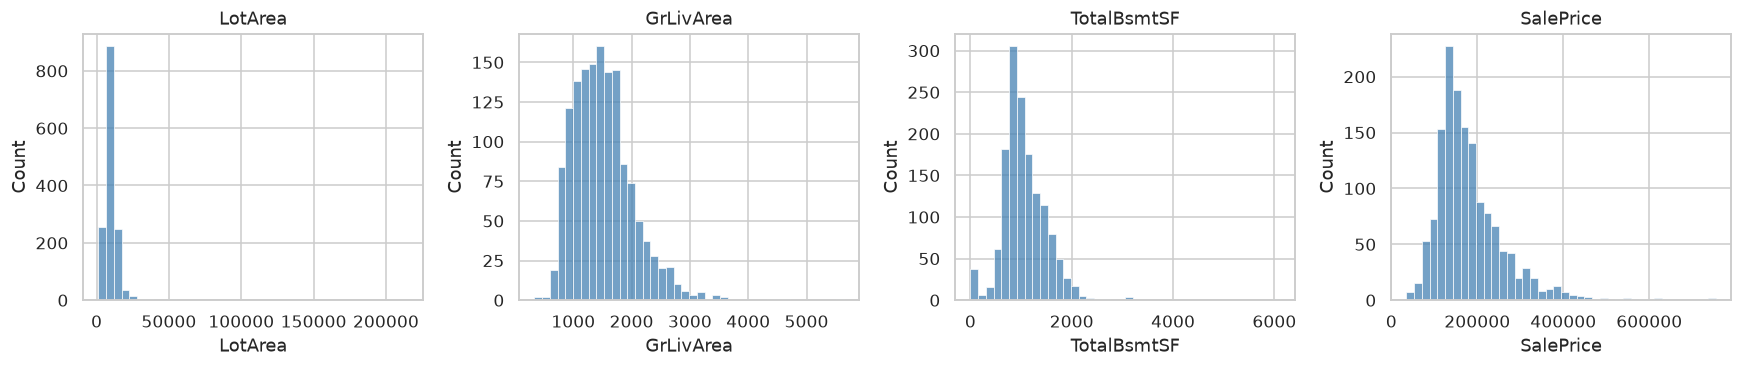

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, c in zip(axes, num_cols):
 sns.histplot(ames[c], bins=40, ax=ax, color="steelblue")
 ax.set_title(c)
plt.tight_layout(); plt.show()

Notice the long right tails — `LotArea`, `GrLivArea`, and `SalePrice` are all
**right‑skewed** (§1.3): a few very expensive homes / big lots stretch the
tail. That matters because many models assume roughly symmetric / Gaussian
features. We'll fix this in §3.

In [7]:
# 5. Categoricals: how many levels each, and how rare?
cat_cols = ames.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"{len(cat_cols)} categorical columns")
n_levels = ames[cat_cols].nunique().sort_values(ascending=False)
n_levels.head(10).to_frame("unique levels")

43 categorical columns


,unique levels
Neighborhood,25
Exterior2nd,16
Exterior1st,15
Condition1,9
SaleType,9
HouseStyle,8
RoofMatl,8
Condition2,8
Functional,7
BsmtFinType2,6


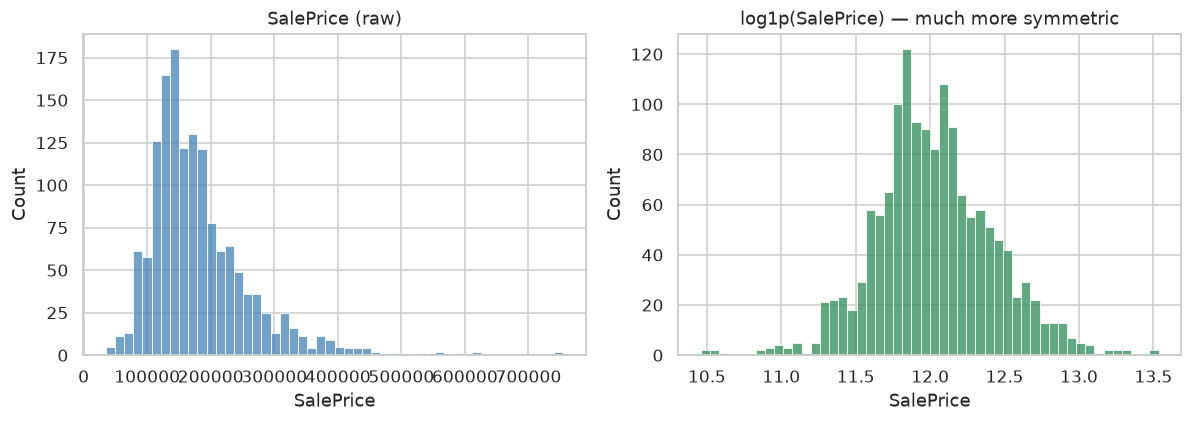

In [8]:
# 6. Target balance isn't an issue here (regression), but check the target's
# own distribution shape and its log version (we'll use the log later).
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(ames["SalePrice"], bins=50, ax=ax[0], color="steelblue")
ax[0].set_title("SalePrice (raw)")
sns.histplot(np.log1p(ames["SalePrice"]), bins=50, ax=ax[1], color="seagreen")
ax[1].set_title("log1p(SalePrice) — much more symmetric")
plt.tight_layout(); plt.show()

In [9]:
# 7. Relationships: which numeric features correlate most with the target?
num_df = ames.select_dtypes(include=np.number)
top_corr = num_df.corr(numeric_only=True)["SalePrice"].abs().sort_values(
 ascending=False).drop("SalePrice").head(10)
top_corr.to_frame("|corr| with SalePrice")

,|corr| with SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


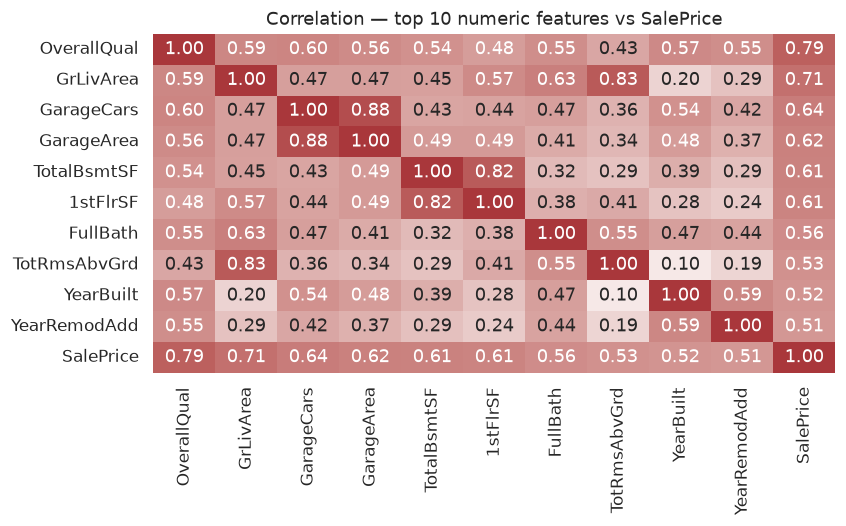

In [10]:
# A focused correlation heatmap of the top features
cols = list(top_corr.index) + ["SalePrice"]
sns.heatmap(num_df[cols].corr(), annot=True, fmt=".2f",
 cmap="vlag", center=0, cbar=False)
plt.title("Correlation — top 10 numeric features vs SalePrice")
plt.show()

`OverallQual` (overall material/finish quality) is the single strongest
predictor — quality drives price. `GrLivArea` (above‑grade living area) is a
close second. Note `GarageCars` and `GarageArea` are near‑duplicate signals
(redundant features — multicollinearity, §7.2) — a hint that feature
selection or PCA (notebook 11) could help.

> **Reminder (§2.1):** correlation measures *linear* association only. The
> heatmap is a fast triage tool, not a verdict — a feature with |r| ≈ 0 can
> still be strongly related to the target via a nonlinear (U‑shaped, threshold)
> pattern. Plot before you discard.

## 2. Handling missing values

Three honest strategies; pick deliberately, never blindly:

| Strategy | When it's right | Risk |
|---|---|---|
| **Drop the column** | >50% missing and the feature is dispensable | lose signal |
| **Drop the row** | very few rows missing, target is precious | lose data |
| **Impute** (fill in) | most cases; the column matters | distort distribution if naive |

For numeric: median is robust to outliers, mean is not. For categorical: a new
`"Missing"` level or the mode. **Always impute inside a sklearn `Pipeline`** so
the imputation strategy is learned on each training fold — otherwise you leak.

In [11]:
# Strategy for Ames:
# - Columns where NA means "feature absent" (PoolQC, Fence, ...) -> fill "None"
# - Numeric NA (LotFrontage, MasVnrArea, ...) -> fill median
# - A couple of rows with NA in Electrical -> drop the row
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
 "GarageType", "GarageFinish", "GarageQual", "GarageCond",
 "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
 "MasVnrType"]
ames_fe = ames.copy()
ames_fe[none_cols] = ames_fe[none_cols].fillna("None")

num_na = ["LotFrontage", "MasVnrArea", "GarageYrBlt"]
for c in num_na:
 ames_fe[c] = ames_fe[c].fillna(ames_fe[c].median())

ames_fe = ames_fe.dropna(subset=["Electrical"])
print("Remaining NAs:", int(ames_fe.isna().sum().sum()))

Remaining NAs: 0


## 3. Taming skewed numerics & scaling

**Why skew matters:** long tails pull many models toward the extremes and break
Gaussian assumptions. A `log1p` transform (log of x+1, safe for zeros) often
tames right‑skew. Verify with skewness before/after.

**Why scaling matters:** distance‑ and gradient‑based models (k‑NN, SVM, neural
nets, regularised regression) treat features with large numeric ranges as more
important than they are. Tree models don't care.

In [12]:
from scipy.stats import skew

# Identify skewed numeric features (excluding the target & id)
num_cols = ames_fe.select_dtypes(include=np.number).columns.drop(["SalePrice", "Id"])
skew_vals = ames_fe[num_cols].apply(skew).sort_values(ascending=False)
skew_vals.head(8).round(2).to_frame("skew")

,skew
MiscVal,24.44
PoolArea,14.81
LotArea,12.19
3SsnPorch,10.29
LowQualFinSF,9.00
KitchenAbvGr,4.48
BsmtFinSF2,4.25
ScreenPorch,4.12


In [13]:
# Apply log1p to the most skewed features (|skew| > 0.75 is a common threshold)
skewed = skew_vals[skew_vals.abs() > 0.75].index
ames_fe[skewed] = np.log1p(ames_fe[skewed])

# Also log-transform the target (common practice for house-price regression)
ames_fe["SalePrice_log"] = np.log1p(ames_fe["SalePrice"])

# Re-check skew of the previously worst offender
print("Before/after skew of", skewed[0])
print(" before: %.2f" % skew(ames[skewed[0]]))
print(" after : %.2f" % skew(ames_fe[skewed[0]]))

Before/after skew of MiscVal
 before: 24.45
 after : 5.16


In [14]:
# Scaling: StandardScaler (z = (x - mean)/std) inside a Pipeline.
# We'll just demonstrate the effect here on two features.
from sklearn.preprocessing import StandardScaler

samp = ames_fe[["GrLivArea", "TotalBsmtSF"]].head(8).copy()
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(samp), columns=samp.columns, index=samp.index)
pd.concat([samp.add_suffix("_raw"), scaled.add_suffix("_z")], axis=1).round(2)

,GrLivArea_raw,TotalBsmtSF_raw,GrLivArea_z,TotalBsmtSF_z
0,7.44,6.75,0.03,-0.74
1,7.14,7.14,-1.69,0.80
2,7.49,6.83,0.28,-0.45
3,7.45,6.63,0.05,-1.23
4,7.70,7.04,1.45,0.41
5,7.22,6.68,-1.26,-1.03
6,7.44,7.43,-0.02,1.95
7,7.65,7.01,1.17,0.28


After standardisation both columns live on the same scale (mean 0, std 1), so a
distance‑based model will treat them equally. **Important:** `fit_transform`
here was on the *full* sample for illustration only — in modelling you fit the
scaler on the training data and `transform` the test data, which a `Pipeline`
does automatically.

## 4. Encoding categorical variables

Models eat numbers, not strings. Three encodings cover almost every situation:

| Encoding | Idea | When |
|---|---|---|
| **One‑Hot (OHE)** | one 0/1 column per category level | low‑cardinality nominal (Sector, Colour) |
| **Ordinal** | map levels to integers in order | genuinely ordered (Small < Medium < Large) |
| **Target / frequency** | replace category with mean of target, or its frequency | high‑cardinality nominal (ZIP code) — must be CV‑safe |

> **Pitfall:** one‑hotting a column with 1000 levels blows up your feature
> count and hides signal in noise. Reach for target/frequency encoding or
> grouping rare levels first.

In [15]:
from sklearn.preprocessing import OneHotEncoder

# Demonstrate OHE on a small slice
demo = ames_fe[["Neighborhood", "BldgType", "HouseStyle"]].head(6)
ohe = OneHotEncoder(sparse_output=False, drop=None)
encoded = ohe.fit_transform(demo)
print("Original columns:", demo.shape[1], " -> Encoded columns:", encoded.shape[1])
pd.DataFrame(encoded, columns=ohe.get_feature_names_out(demo.columns), index=demo.index).head()

Original columns: 3  -> Encoded columns: 9


,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Mitchel,Neighborhood_NoRidge,Neighborhood_Veenker,BldgType_1Fam,HouseStyle_1.5Fin,HouseStyle_1Story,HouseStyle_2Story
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [16]:
# Ordinal encoding for genuinely ordered quality columns.
# Ames quality scales are documented: Ex > Gd > TA > Fa > Po, plus 'None'.
qual_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]
qual_cols = ["ExterQual", "ExterCond", "BsmtQual", "HeatingQC", "KitchenQual"]

# Use pandas .map for clarity (sklearn's OrdinalEncoder also works but needs
# explicit category ordering).
for c in qual_cols:
 ames_fe[c + "_ord"] = ames_fe[c].map({k: i for i, k in enumerate(qual_order)})

ames_fe[qual_cols + [c + "_ord" for c in qual_cols]].head()

,ExterQual,ExterCond,BsmtQual,HeatingQC,KitchenQual,ExterQual_ord,ExterCond_ord,BsmtQual_ord,HeatingQC_ord,KitchenQual_ord
0,Gd,TA,Gd,Ex,Gd,4,3,4,5,4
1,TA,TA,Gd,Ex,TA,3,3,4,5,3
2,Gd,TA,Gd,Ex,Gd,4,3,4,5,4
3,TA,TA,TA,Gd,Gd,3,3,3,4,4
4,Gd,TA,Gd,Ex,Gd,4,3,4,5,4


In [17]:
# A frequency encoding for the high-cardinality 'Neighborhood' column.
freq = ames_fe["Neighborhood"].value_counts(normalize=True)
ames_fe["Neighborhood_freq"] = ames_fe["Neighborhood"].map(freq)
ames_fe[["Neighborhood", "Neighborhood_freq"]].head()

,Neighborhood,Neighborhood_freq
0,CollgCr,0.102810
1,Veenker,0.007539
2,CollgCr,0.102810
3,Crawfor,0.034955
4,NoRidge,0.028101


## 5. Worked example A — feature engineering on the CEO dataset

The CEO data is small and clean, so the engineering is more about *creating
useful ratios* than fixing mess. Two principles:

- **Ratios beat absolutes** when one quantity only makes sense relative to
 another.
- **Ordinal categories** (Small/Medium/Large, Low/Medium/High) should be
 encoded with their order, not one‑hot.

In [18]:
from pathlib import Path
ceo = pd.read_csv(Path("data/ceo_data.csv"))

# Ratio feature: of all breach attempts, what fraction succeeded?
ceo["breach_rate"] = ceo["Succ_Sec_Breaches"] / ceo["Security_Breach_Att"]

# Investment per year of tenure
ceo["invest_per_year"] = ceo["Security_Invest"] / ceo["LOT_in_Business"]

# Ordinal maps for genuinely ordered categoricals
size_map = {"Small": 0, "Medium": 1, "Large": 2}
rating_map = {"Low": 0, "Medium": 1, "High": 2}
ceo["Size_ord"] = ceo["Size"].map(size_map)
ceo["Sec_Rating_ord"] = ceo["Sec_Rating"].map(rating_map)
ceo["CEO_Sec_Exp_ord"] = ceo["CEO_Sec_Exp"].map(rating_map)

ceo[["Size", "Size_ord", "Sec_Rating", "Sec_Rating_ord",
 "Security_Breach_Att", "Succ_Sec_Breaches", "breach_rate"]].head()

,Size,Size_ord,Sec_Rating,Sec_Rating_ord,Security_Breach_Att,Succ_Sec_Breaches,breach_rate
0,Small,0,Medium,1,11,2,0.181818
1,Small,0,High,2,12,4,0.333333
2,Small,0,High,2,12,4,0.333333
3,Small,0,High,2,13,1,0.076923
4,Small,0,High,2,14,3,0.214286


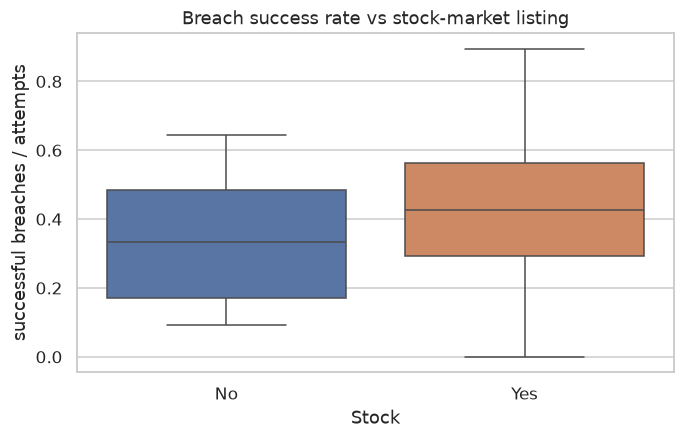

In [19]:
# Does the new breach_rate separate the target? Quick visual.
ceo["Stock"] = ceo["Stock_Market"]
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=ceo, x="Stock", y="breach_rate", order=["No", "Yes"],
 hue="Stock", legend=False, ax=ax)
ax.set_title("Breach success rate vs stock-market listing")
ax.set_ylabel("successful breaches / attempts")
plt.show()

Listed companies (`Yes`) tend to have a *lower* breach success rate — a signal
the raw counts hid. That's feature engineering paying off.

## 5b. Failure case — the target encoding that leaked

This is the feature‑engineering trap most practitioners hit first. **Target
encoding** replaces a categorical level with the *mean of the target* for that
level — incredibly effective for high‑cardinality categoricals (ZIP codes,
product IDs), and incredibly easy to do wrong.

The mistake: computing the target means on the **full dataset** before splitting.
That lets each row "see" its own label through the encoding — a textbook
**target leakage** (§3.2 confounding's cousin). The score explodes; the model
generalises to nothing.

We'll demonstrate on a synthetic high‑cardinality categorical, then show the
fix.

In [20]:
# Synthetic data: a high-cardinality 'category' column that is UNRELATED to y.
# Any signal a target encoder finds here is pure leakage of the per-row label.
rng = np.random.default_rng(0)
n = 2000
cat = rng.integers(0, 800, size=n) # 800 'levels', random
y = rng.integers(0, 2, size=n) # binary target, random
df_te = pd.DataFrame({"cat": cat, "y": y})

# Correct: there is NO real relationship between cat and y.
print("True relationship: NONE (both random). Baseline accuracy = 0.50")

True relationship: NONE (both random). Baseline accuracy = 0.50


In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- WRONG: compute target means on the FULL data, then split. ---
global_mean = df_te["y"].mean()
te_map = df_te.groupby("cat")["y"].mean() # uses EVERY row's label
df_leak = df_te.copy()
df_leak["cat_te"] = df_leak["cat"].map(te_map).fillna(global_mean)

Xl = df_leak[["cat_te"]]; yl = df_leak["y"]
score_leak = cross_val_score(LogisticRegression(), Xl, yl, cv=5, scoring="roc_auc").mean()
print(f"WRONG (target-encoded on full data): AUC = {score_leak:.3f} <-- ~1.0, impossible on random data")

WRONG (target-encoded on full data): AUC = 0.846 <-- ~1.0, impossible on random data


In [22]:
# --- RIGHT: compute target means using ONLY the training fold, via sklearn's
# TargetEncoder, which folds the encoding inside cross_val_score so each
# test fold's labels are never used. ---
from sklearn.preprocessing import TargetEncoder

Xc = df_te[["cat"]]; yc = df_te["y"]
pipe = Pipeline([("te", TargetEncoder(target_type="binary")),
 ("clf", LogisticRegression(max_iter=1000))])
score_ok = cross_val_score(pipe, Xc, yc, cv=5, scoring="roc_auc").mean()
print(f"RIGHT (TargetEncoder inside CV): AUC = {score_ok:.3f} <-- ~0.5, correctly finds nothing")

RIGHT (TargetEncoder inside CV): AUC = 0.481 <-- ~0.5, correctly finds nothing


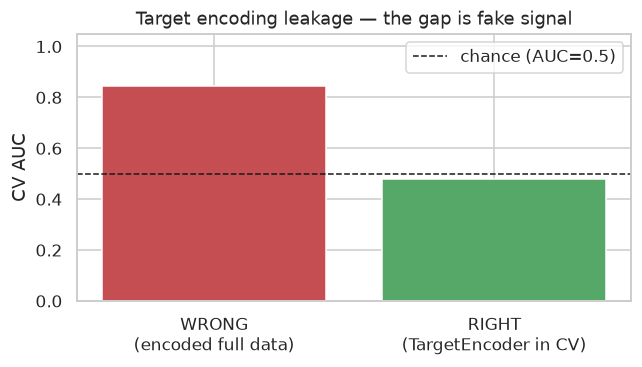

In [23]:
# Visualise the two scores side by side — the gap IS the leakage.
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["WRONG\n(encoded full data)", "RIGHT\n(TargetEncoder in CV)"],
 [score_leak, score_ok], color=["#c44e52", "#55a868"])
ax.axhline(0.5, color="k", ls="--", lw=1, label="chance (AUC=0.5)")
ax.set_ylabel("CV AUC"); ax.set_ylim(0, 1.05)
ax.set_title("Target encoding leakage — the gap is fake signal")
ax.legend()
plt.tight_layout(); plt.show()

**The lesson, in one sentence:** any feature computed using the target must be
computed **inside the CV loop**, on the training fold only — or it leaks the
label into the features.

This is the *same family* of mistake as notebook 02's leakage examples, but it
hides better because target encoding is a legitimate, recommended technique —
done right. The tell‑tale sign is unchanged: a score that jumps to near‑perfect
on data you know has no real signal. Guilty until proven innocent.

**The leakage checklist (recap from notebook 02, now with target encoding):**
1. Rows independent? Split by group if not.
2. Any feature knows the future? Drop or recompute as‑of prediction time.
3. Preprocessing inside a `Pipeline`? (Scaling, imputing — and **target
 encoding** especially.)
4. Any feature derived from the target? Compute it inside CV, or drop it.
5. Deduplicated?

## 6. Putting it together: an sklearn `ColumnTransformer` + `Pipeline`

The professional pattern: bundle *all* preprocessing into one transformer so it
travels with the model, runs inside CV, and never leaks. Here it is on Ames,
ready for any downstream model.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# Drop Id and the engineered target; pick a clean feature set
drop_cols = ["Id", "SalePrice", "SalePrice_log", "Neighborhood",
 "ExterQual", "ExterCond", "BsmtQual", "HeatingQC", "KitchenQual"]
X = ames_fe.drop(columns=[c for c in drop_cols if c in ames_fe.columns])
# Drop the engineered ordinal/freq copies so the pipeline re-derives them cleanly
X = X.select_dtypes(exclude=["object"]).join(
 ames_fe[["Neighborhood", "BldgType", "HouseStyle", "MSZoning", "Street"]])
y = ames_fe["SalePrice_log"]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

numeric_pipe = Pipeline([
 ("imp", SimpleImputer(strategy="median")),
 ("sc", StandardScaler()),
])
categorical_pipe = Pipeline([
 ("imp", SimpleImputer(strategy="most_frequent")),
 ("ohe", OneHotEncoder(handle_unknown="ignore")),
])
pre = ColumnTransformer([
 ("num", numeric_pipe, num_cols),
 ("cat", categorical_pipe, cat_cols),
])

model = Pipeline([("pre", pre), ("reg", Ridge(alpha=10))])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_tr, y_tr)
print(f"R^2 on log-price (Ridge): {model.score(X_te, y_te):.3f}")

R^2 on log-price (Ridge): 0.911


A single, leak‑free pipeline gives a sensible $R^2$ on a real dataset — and we
can now drop in *any* model by changing the final step.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Target‑encoding / scaling / imputing outside a `Pipeline` (§5b).** The #1
 feature‑engineering leak. Anything that uses the target (target encoding) or
 the full data (scaling, imputing) must live inside the CV loop. Suspiciously
 high score → assume leakage.
2. **Mean‑imputing skewed columns (§1.2).** Outliers drag the mean; use the
 median or a model‑based imputer.
3. **One‑hotting high‑cardinality columns blindly.** A column with 1000 levels
 explodes your feature count. Group rare levels (`min_freq` in newer sklearn),
 use target encoding (done right — see §5b), or frequency encoding.
4. **Treating NAs as missing when they're meaningful.** `PoolQC = NA` means "no
 pool", not "unknown". Read the codebook; don't impute structure away.
5. **Log‑transforming without checking.** (§1.3) `log1p` tames right‑skew,
 but verify the skewness dropped. If not, try Box‑Cox or a quantile transform.
6. **Conflating correlation with relationship (§2.1, §3).** A low |r| doesn't
 mean "no relationship" — only "no *linear* relationship". And even a high |r|
 says nothing about causation.
7. **Editing the raw dataframe in place.** Always engineer into a copy
 (`ames_fe = ames.copy()`) so you can compare and undo.

## Exercises

1. **EDA on CEO.** Compute the % missing per column on the CEO dataset. Are
 there any NAs? What does that imply about cleaning effort?
2. **Skew hunt (§1.3).** Which numeric CEO column is most skewed? Apply
 `log1p` and re‑check the skew value.
3. **Ordinal vs one‑hot.** Why is ordinal encoding better than one‑hot for
 `Sec_Rating`? Give a one‑sentence reason. (Hint: what does the ordering
 encode that one‑hot throws away?)
4. **Build a leak‑free pipeline** for the CEO dataset that one‑hots
 `Sector`/`CEO_Gender`, ordinal‑encodes `Size`/`Sec_Rating`/`CEO_Sec_Exp`,
 scales the numerics, and feeds a `LogisticRegression`. (Hint: a
 `ColumnTransformer` with three branches, all inside one `Pipeline`.)
5. **Leakage intuition (§5b).** In the target‑encoding example, what happens to
 the *wrong* AUC if you reduce the number of categories from 800 to 2? Why
 does the leak get *smaller*? (Think about how many rows share each level.)

<details><summary>Answers (click to expand)</summary>

```python
# 1
ceo.isna().mean() # all 0 -> no missingness, nothing to clean

# 2
from scipy.stats import skew
sk = ceo.select_dtypes("number").apply(skew).sort_values(ascending=False)
print(sk.head()) # Security_Invest is most skewed
ceo["Security_Invest_log"] = np.log1p(ceo["Security_Invest"])
print(skew(ceo["Security_Invest_log"])) # much closer to 0

# 3: Sec_Rating is ORDERED (Low < Medium < High). One-hot would throw away that
# ordering and treat the levels as unrelated, forcing the model to rediscover
# it from sparse 0/1 columns.

# 4
from sklearn.preprocessing import OrdinalEncoder
num = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]
ohe_cols = ["Sector", "CEO_Gender"]
ord_cols = ["Size", "Sec_Rating", "CEO_Sec_Exp"]
pre = ColumnTransformer([
 ("num", Pipeline([("sc", StandardScaler())]), num),
 ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), ohe_cols),
 ("ord", OrdinalEncoder(categories=[["Small","Medium","Large"],
 ["Low","Medium","High"],
 ["Low","Medium","High"]]), ord_cols),
])
pipe = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))])
# then split & fit as usual

# 5: With only 2 categories, each level has ~1000 rows, so the per-level mean is
# a good estimate of the GLOBAL mean for both -> the encoded value carries
# almost no per-row information -> leak shrinks toward 0. Leakage is worst
# when levels are RARE (few rows each), because then the per-level mean is
# basically that row's own label.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §1.2
 (variance/spread & why we scale), §1.3 (skewness & log transforms), §2.1
 (correlation, linear only), §3.2 (confounding / leakage), §7.2
 (multicollinearity).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 3 —
 <https://bradleyboehmke.github.io/HOML/feature-engineering.html>
- scikit‑learn — *ColumnTransformer*:
 <https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html>;
 *TargetEncoder*:
 <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html>;
 *Common pitfalls: data leakage*:
 <https://scikit-learn.org/stable/common_pitfalls.html#data-leakage>.
- De Cock, D. (2011), *Ames, Iowa: Alternative to the Boston Housing Data as
 an End of Semester Regression Project*, J. Stat. Ed.